In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [7]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("naturalNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
rhloopstring = "resid 326:349"
#combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+rhloopstring+")"))
        sub2.append("protein and not ("+rhloopstring+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
rhloopstring = "resid 326:349"
#combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+rhloopstring))
        sub2.append("protein and "+rhloopstring)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [8]:
def getSSByRes(trjpaths,tprpaths,EQPOINT):
    
    helicityMap={"H":1,"E":0,"C":0}
    betacityMap={"H":0,"E":1,"C":0}
    coilicityMap={"H":0,"E":0,"C":1}
    
    helicity= []
    betacity= []
    coilicity=[]
    
    herr=[]
    berr=[]
    cerr=[]
    
    for i in range(len(trjpaths)):
        subH=[]
        subE=[]
        subC=[]
        for j in range(len(trjpaths[i])):
            t=mdtraj.load(trjpaths[i][j],top=tprpaths[i][j])
            ss1=mdtraj.compute_dssp(t,simplified=True)
            H1=zeros(ss1.shape)
            E1=zeros(ss1.shape)
            C1=zeros(ss1.shape)
            
            for ii in range(len(H1)):
                for jj in range(len(H1[ii])):
                    H1[ii][jj]=helicityMap[ss1[ii][jj]]
                    E1[ii][jj]=betacityMap[ss1[ii][jj]]
                    C1[ii][jj]=coilicityMap[ss1[ii][jj]]
                    
            H1byRes=mean(H1[EQPOINT:],axis=0)
            subH.append(H1byRes)
            
            E1byRes=mean(E1[EQPOINT:],axis=0)
            subE.append(E1byRes)
            C1byRes=mean(C1[EQPOINT:],axis=0)
            subC.append(C1byRes)
            
        helicity.append(subH)
        betacity.append(subE)
        coilicity.append(subC)

    return helicity,betacity,coilicity


helicity,betacity,coilcity=getSSByRes(systemtrjs,systemgros,EQPOINT=EQPOINT)


C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ARG, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (CYS, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (GLU, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

In [11]:
len(helicity[0])

9

In [26]:
mean_helicity = mean(helicity[0],axis = 0)
sem_helicity = scipy.stats.sem(helicity[0],axis = 0)

Text(0.5, 1.0, 'Rhesus V1 Helicity')

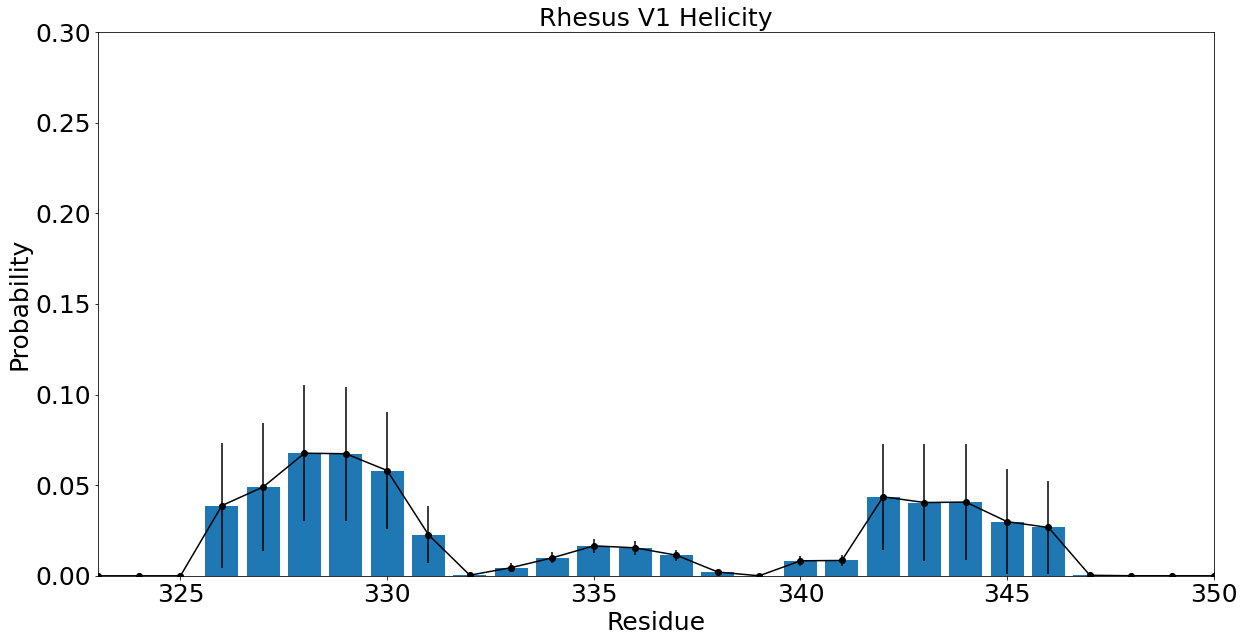

In [32]:
figure(figsize = (20,10))
bar(rhresids,mean_helicity)
errorbar(rhresids,mean_helicity,sem_helicity,color = "black",marker = "o")
xlim(323,350)
ylim(0,0.3)

_=xticks(fontsize = 25)
_=yticks(fontsize = 25)

xlabel("Residue",fontsize = 25)
ylabel("Probability",fontsize = 25)
title("Rhesus V1 Helicity",fontsize = 25)